In [3]:
import functions as fn
from mastu import HSV
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import my_funcs as mf
import numpy as np
from pyEquilibrium.equilibrium import equilibrium as equil
import pyuda
client = pyuda.Client()
from scipy.interpolate import interp2d, RegularGridInterpolator
import sys

-------------------Loading module Divertor-------------------
-------------------Loading module Utilities-------------------
kk_cz couldnt be imported (SyntaxError)
dd couldnt be imported


In [4]:
%matplotlib widget

In [5]:
file = np.load('/home/sthoma/Documents/Results/rba/49091/testing_newRz.npz')

R = file['R']
data = file['data']
err = file['err']
time = file['time']
Rgrid = file['Rgrid']
RgridB = file['RgridB']
y = file['y']
yErr = file['yErr']
backprojection = file['backprojection']
scale = file['scale']

In [24]:
def mtanh(R, R0, height, width, grad, bkgd):
    ###
    z = -4. * (R - R0) / width
    L = 1. / (1. + np.exp(-z))
    profile = (L * (height - bkgd + ((z * width * grad) / 4.))) + bkgd
    return profile

In [7]:
shotn = 49091
twant = time[0]

psind = mf.find_nearest(RgridB, 1.)
eq = equil(device='mastu', shot=shotn, time=twant)
psiN = mf.getRho(shotn, twant, RgridB[psind:], 0.)[0][0]
sepR = np.interp(1., psiN, RgridB[psind:])

def forward(x):
    return np.interp(x, RgridB[psind:], psiN)
def inverse(x):
    return np.interp(x, psiN, RgridB[psind:])

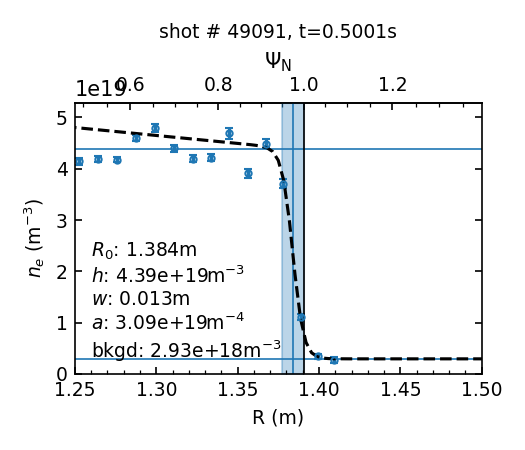

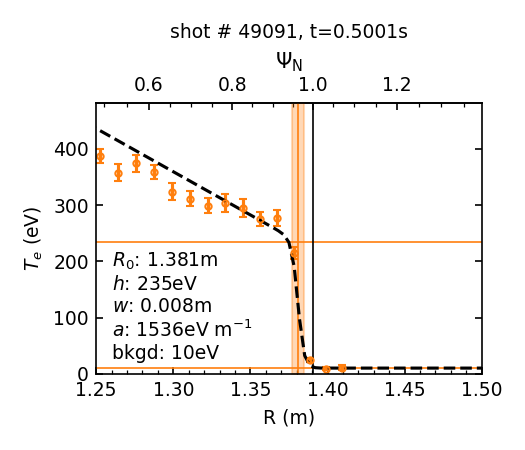

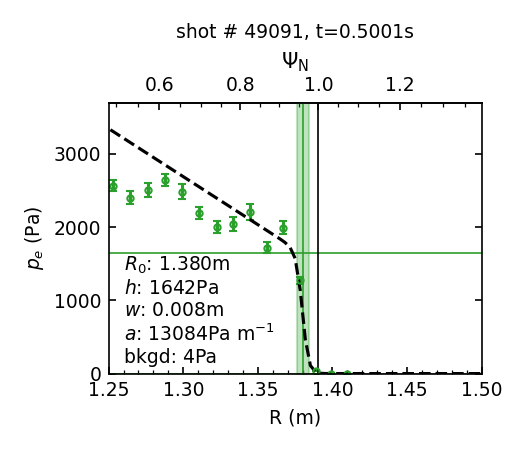

In [8]:
R0 = 1.25 # where the fit should be valid to
R1 = 1.50 # for the plots
y0 = 0.
yMult = 1.1 # for the ylim in the plots
dR = 0.01
dyDensity = 0.2e19
dyTemp = 20.
dyPressure = 100.


timePed = client.get('/apf/core/mtanh/lfs/time', shotn).data
tind = HSV.findNearest(timePed, twant)


R0Density = client.get('/apf/core/mtanh/lfs/n_e/pedestal_location', shotn).data[tind]
heightDensity = client.get('/apf/core/mtanh/lfs/n_e/pedestal_height', shotn).data[tind]
widthDensity = client.get('/apf/core/mtanh/lfs/n_e/pedestal_width', shotn).data[tind]
gradDensity = client.get('/apf/core/mtanh/lfs/n_e/pedestal_top_gradient', shotn).data[tind]
bkgdDensity = client.get('/apf/core/mtanh/lfs/n_e/background_level', shotn).data[tind]
paramsDensity = (
    R0Density, heightDensity, widthDensity, gradDensity, bkgdDensity
)
textDensity = f'\
$R_0$: {R0Density:.3f}m\n\
$h$: {heightDensity:.3g}m$^{{-3}}$\n\
$w$: {widthDensity:.3f}m\n\
$a$: {gradDensity:.3g}m$^{{-4}}$\n\
bkgd: {bkgdDensity:.3g}m$^{{-3}}$'

R0Temp = client.get('/apf/core/mtanh/lfs/T_e/pedestal_location', shotn).data[tind]
heightTemp = client.get('/apf/core/mtanh/lfs/T_e/pedestal_height', shotn).data[tind]
widthTemp = client.get('/apf/core/mtanh/lfs/T_e/pedestal_width', shotn).data[tind]
gradTemp = client.get('/apf/core/mtanh/lfs/T_e/pedestal_top_gradient', shotn).data[tind]
bkgdTemp = client.get('/apf/core/mtanh/lfs/T_e/background_level', shotn).data[tind]
paramsTemp = (
    R0Temp, heightTemp, widthTemp, gradTemp, bkgdTemp
)
textTemp = f'\
$R_0$: {R0Temp:.3f}m\n\
$h$: {heightTemp:.0f}eV\n\
$w$: {widthTemp:.3f}m\n\
$a$: {gradTemp:.0f}eV m$^{{-1}}$\n\
bkgd: {bkgdTemp:.0f}eV'

R0Pressure = client.get('/apf/core/mtanh/lfs/p_e/pedestal_location', shotn).data[tind]
heightPressure = client.get('/apf/core/mtanh/lfs/p_e/pedestal_height', shotn).data[tind]
widthPressure = client.get('/apf/core/mtanh/lfs/p_e/pedestal_width', shotn).data[tind]
gradPressure = client.get('/apf/core/mtanh/lfs/p_e/pedestal_top_gradient', shotn).data[tind]
bkgdPressure = client.get('/apf/core/mtanh/lfs/p_e/background_level', shotn).data[tind]
paramsPressure = (
    R0Pressure, heightPressure, widthPressure, gradPressure, bkgdPressure
)
textPressure = f'\
$R_0$: {R0Pressure:.3f}m\n\
$h$: {heightPressure:.0f}Pa\n\
$w$: {widthPressure:.3f}m\n\
$a$: {gradPressure:.0f}Pa m$^{{-1}}$\n\
bkgd: {bkgdPressure:.0f}Pa'


Rind = HSV.findNearest(RgridB, R0)
profileDensity = mtanh(RgridB, *paramsDensity)
y1Density = profileDensity[Rind] * yMult
profileTemp = mtanh(RgridB, *paramsTemp)
y1Temp = profileTemp[Rind] * yMult
profilePressure = mtanh(RgridB, *paramsPressure)
y1Pressure = profilePressure[Rind] * yMult


timeThomson = client.get('/ayc/time', shotn).data
tind0 = HSV.findNearest(timeThomson, twant)

ne, neErr, RThomson = mf.getNe(shotn)
ne = ne.data[tind0]
neErr = neErr[tind0]

Te, TeErr, _ = mf.getTe(shotn)
Te = Te.data[tind0]
TeErr = TeErr[tind0]

Pe, PeErr, _ = mf.getPe(shotn)
Pe = Pe.data[tind0]
PeErr = PeErr[tind0]

RThomson = RThomson[tind0]
indRTh = mf.find_nearest(RThomson, R0)


fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot([R0, R1], [heightDensity, heightDensity], '-', c='C0', lw=0.8)
ax.plot([R0, R1], [bkgdDensity, bkgdDensity], '-', c='C0', lw=0.8)
ax.plot([R0Density, R0Density], [y0, y1Density], '-', c='C0', lw=0.8)
ax.fill_between(
    [R0Density-widthDensity*0.5, R0Density+widthDensity*0.5], 
    [y0, y0], [y1Density, y1Density], color='C0', alpha=0.3, 
)
ax.errorbar(RThomson, ne, yerr=neErr, fmt='.', c='C0', mfc='None', capsize=2)
ax.plot(RgridB, profileDensity, '--k')
ax.set_xlim([R0, R1])
ax.set_ylim([y0, y1Density])
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('$n_e$ (m$^{-3}$)', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=False
)
ax.xaxis.set_minor_locator(AutoMinorLocator())
secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.xaxis.set_minor_locator(AutoMinorLocator())
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=False, bottom=False, right=False, top=True
)
secax.minorticks_on()
ax.plot([sepR, sepR], [y0, y1Density], '-k', lw=0.8)
ax.set_title(f'shot # {shotn:.0f}, t={timePed[tind]:.4f}s', fontsize=9)
ax.text(R0+dR, y0+dyDensity, textDensity, ha='left', va='bottom', fontsize=9)
plt.tight_layout()


fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot([R0, R1], [heightTemp, heightTemp], '-', c='C1', lw=0.8)
ax.plot([R0, R1], [bkgdTemp, bkgdTemp], '-', c='C1', lw=0.8)
ax.plot([R0Temp, R0Temp], [y0, y1Temp], '-', c='C1', lw=0.8)
ax.fill_between(
    [R0Temp-widthTemp*0.5, R0Temp+widthTemp*0.5], 
    [y0, y0], [y1Temp, y1Temp], color='C1', alpha=0.3, 
)
ax.errorbar(RThomson, Te, yerr=TeErr, fmt='.', c='C1', mfc='None', capsize=2)
ax.plot(RgridB, profileTemp, '--k')
ax.set_xlim([R0, R1])
ax.set_ylim([y0, y1Temp])
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('$T_e$ (eV)', fontsize=9)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=False
)
secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.xaxis.set_minor_locator(AutoMinorLocator())
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
            left=False, bottom=False, right=False, top=True)
secax.minorticks_on()
ax.plot([sepR, sepR], [y0, y1Temp], '-k', lw=0.8)
ax.set_title(f'shot # {shotn:.0f}, t={timePed[tind]:.4f}s', fontsize=9)
ax.text(R0+dR, y0+dyTemp, textTemp, ha='left', va='bottom', fontsize=9)
plt.tight_layout()


fig, ax = plt.subplots(1, 1, figsize=(3.5,3), dpi=150)
ax.plot([R0, R1], [heightPressure, heightPressure], '-', c='C2', lw=0.8)
ax.plot([R0, R1], [bkgdPressure, bkgdPressure], '-', c='C2', lw=0.8)
ax.plot([R0Pressure, R0Pressure], [y0, y1Pressure], '-', c='C2', lw=0.8)
ax.fill_between(
    [R0Pressure-widthPressure*0.5, R0Pressure+widthPressure*0.5], 
    [y0, y0], [y1Pressure, y1Pressure], color='C2', alpha=0.3, 
)
ax.errorbar(RThomson, Pe, yerr=PeErr, fmt='.', c='C2', mfc='None', capsize=2)
ax.plot(RgridB, profilePressure, '--k')
ax.set_xlim([R0, R1])
ax.set_ylim([y0, y1Pressure])
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('$p_e$ (Pa)', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=False
)
ax.xaxis.set_minor_locator(AutoMinorLocator())
secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.xaxis.set_minor_locator(AutoMinorLocator())
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=False, bottom=False, right=False, top=True
)
secax.minorticks_on()
ax.plot([sepR, sepR], [y0, y1Pressure], '-k', lw=0.8)
ax.set_title(f'shot # {shotn:.0f}, t={timePed[tind]:.4f}s', fontsize=9)
ax.text(R0+dR, y0+dyPressure, textPressure, ha='left', va='bottom', fontsize=9)
plt.tight_layout()

In [9]:
excit = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/EXCIT_pec12#h_pju#h0.npz')
ne0 = excit['ne']#[13:20]
Te0 = excit['Te']#[4:23]
dataExcite = excit['data']#[13:20,4:23]
### units of [ph m^3 /s]
recom = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/RECOM_pec12#h_pju#h0.npz')
dataRecomb = recom['data']#[13:20,4:23]
### units of [ph m^3 /s]
ionis = np.load('/home/sthoma/tokamak_inversion_routines/ADAS/IONIS_scd12h.npz')
dataIonise = ionis['data']#[13:20,4:23]
### units of [m^3 /s]

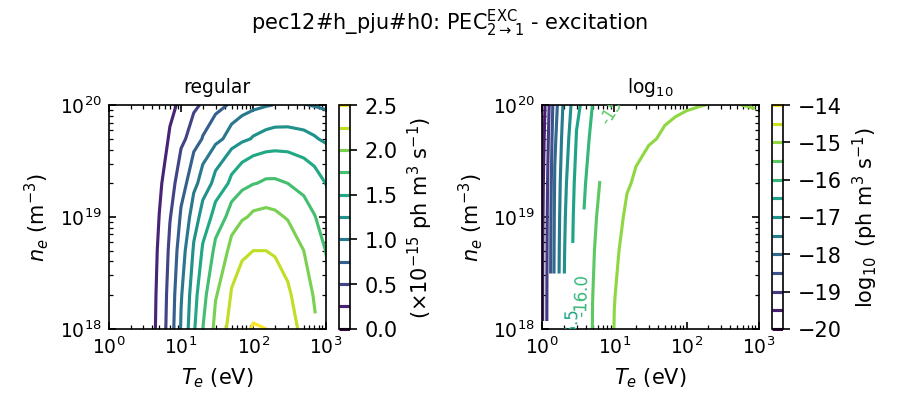

In [10]:
cmap=plt.cm.viridis

fig, ax = plt.subplots(1, 2, figsize=(6,2.75), dpi=150)


N = 15
levels = np.linspace(0., 2.5e-15*(10**N), 11)
cf = ax[0].contour(Te0, ne0, dataExcite*(10**N), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[0], ticks=levels[::2], 
    label=f'($\\times10^{{{-N:.0f}}}$ ph m$^3$ s$^{{-1}}$)'
)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=5, use_clabeltext=False
)
ax[0].set_xlabel('$T_e$ (eV)')
ax[0].set_ylabel('$n_e$ (m$^{-3}$)')
ax[0].set_xlim([1e0,1e3])
ax[0].set_ylim([1e18,1e20])
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_title('regular', fontsize=9)


levels = np.linspace(-20, -14, 13)
cf = ax[1].contour(Te0, ne0, np.log10(dataExcite), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[1], ticks=levels[::2], 
    label='$\\log_{10}$ (ph m$^3$ s$^{-1}$)'
)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=10, use_clabeltext=False
)
ax[1].set_xlabel('$T_e$ (eV)')
ax[1].set_ylabel('$n_e$ (m$^{-3}$)')
ax[1].set_xlim([1e0,1e3])
ax[1].set_ylim([1e18,1e20])
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_title('$\\log_{10}$', fontsize=9)

fig.suptitle('pec12#h_pju#h0: PEC$^\\mathrm{EXC}_{2 \\rightarrow 1}$ - excitation', fontsize=10)
plt.tight_layout()

In [11]:
# ### excitation
# fExciteLinear = interp2d(Te0, ne0, dataExcite, kind='linear', bounds_error=True)
# fExciteCubic = interp2d(Te0, ne0, dataExcite, kind='cubic', bounds_error=True)

# exciteLinear = np.diag(fExciteLinear(profileTemp[Rind:], profileDensity[Rind:]))[::-1]
# exciteCubic = np.diag(fExciteCubic(profileTemp[Rind:], profileDensity[Rind:]))[::-1]


# fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
# ax.plot(RgridB[Rind:], exciteLinear, 'o', c='C0', mfc='None', label='bi-linear')
# ax.plot(RgridB[Rind:], exciteCubic, '^', c='C1', mfc='None', label='bi-cubic')
# ax.set_title('PEC$^\\mathrm{EXC}_{2 \\rightarrow 1}$ - excitation', fontsize=9)
# ax.legend(fancybox=1, framealpha=1, fontsize=8)
# ax.set_xlabel('R (m)', fontsize=9)
# ax.set_ylabel('Interpolated values', fontsize=9)
# ax.tick_params(
#     axis="both", which='both', labelsize=9, direction='in', 
#     left=True, bottom=True, right=True, top=False
# )
# secax = ax.secondary_xaxis('top', functions=(forward, inverse))
# secax.xaxis.set_minor_locator(AutoMinorLocator())
# secax.set_xlabel('$\\Psi_\\mathrm{N}$')
# secax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
#             left=False, bottom=False, right=False, top=True)
# secax.minorticks_on()
# ax.yaxis.get_offset_text().set_size(9)
# ax.set_xlim([R0, R1])
# plt.tight_layout()

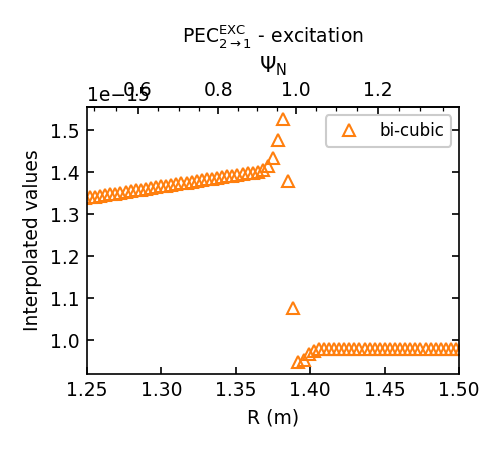

In [12]:
### excitation 
scaleExcite = 10**int(np.log10(np.median(dataExcite)))
fExcite = RegularGridInterpolator(
    (Te0, ne0), 
    dataExcite.T / scaleExcite, 
    method='cubic', 
)
exciteCubic = fExcite((profileTemp[Rind:], profileDensity[Rind:])) * scaleExcite

fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
# ax.plot(RgridB[Rind:], exciteLinear, 'o', c='C0', mfc='None', label='bi-linear')
# ax.plot(RgridB[Rind:], outlinear, '-', c='C0', mfc='None', label='bi-linear2')
ax.plot(RgridB[Rind:], exciteCubic, '^', c='C1', mfc='None', label='bi-cubic')
# ax.plot(RgridB[Rind:], outcubic, '-', c='C1', mfc='None', label='bi-cubic2')
ax.set_title('PEC$^\\mathrm{EXC}_{2 \\rightarrow 1}$ - excitation', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=False
)
secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.xaxis.set_minor_locator(AutoMinorLocator())
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
            left=False, bottom=False, right=False, top=True)
secax.minorticks_on()
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

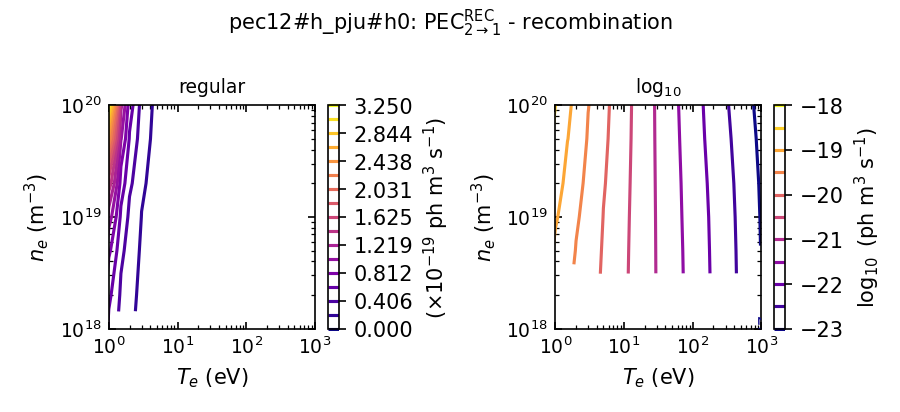

In [13]:
cmap=plt.cm.plasma

fig, ax = plt.subplots(1, 2, figsize=(6,2.75), dpi=150)


N = 19
levels = np.linspace(0., 3.25e-19*(10**N), 17)
cf = ax[0].contour(Te0, ne0, dataRecomb*(10**N), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[0], ticks=levels[::2], 
    label=f'($\\times10^{{{-N:.0f}}}$ ph m$^3$ s$^{{-1}}$)'
)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=5, use_clabeltext=False
)
ax[0].set_xlabel('$T_e$ (eV)')
ax[0].set_ylabel('$n_e$ (m$^{-3}$)')
ax[0].set_xlim([1e0,1e3])
ax[0].set_ylim([1e18,1e20])
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_title('regular', fontsize=9)


levels = np.linspace(-23, -18, 11)
cf = ax[1].contour(Te0, ne0, np.log10(dataRecomb), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[1], ticks=levels[::2], 
    label='$\\log_{10}$ (ph m$^3$ s$^{-1}$)'
)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=10, use_clabeltext=False
)
ax[1].set_xlabel('$T_e$ (eV)')
ax[1].set_ylabel('$n_e$ (m$^{-3}$)')
ax[1].set_xlim([1e0,1e3])
ax[1].set_ylim([1e18,1e20])
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_title('$\\log_{10}$', fontsize=9)

fig.suptitle('pec12#h_pju#h0: PEC$^\\mathrm{REC}_{2 \\rightarrow 1}$ - recombination', fontsize=10)
plt.tight_layout()

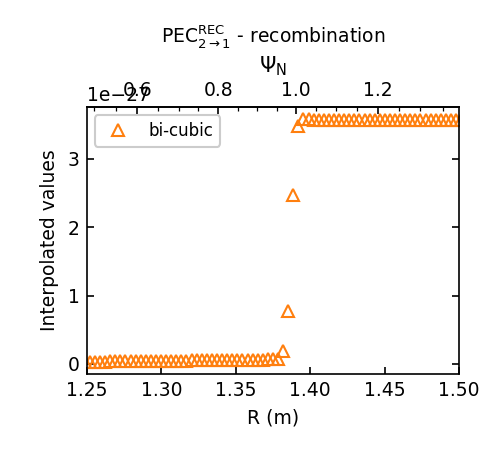

In [14]:
### recombination
# fRecombLinear = interp2d(Te0, ne0, dataRecomb, kind='linear', bounds_error=True)
# fRecombCubic = interp2d(Te0, ne0, dataRecomb, kind='cubic', bounds_error=True)

# recombLinear = np.diag(fRecombLinear(profileTemp[Rind:], profileDensity[Rind:]))[::-1]
# recombCubic = np.diag(fRecombCubic(profileTemp[Rind:], profileDensity[Rind:]))[::-1]
scaleRecomb = 10**int(np.log10(np.median(dataRecomb)))
fRecomb = RegularGridInterpolator(
    (Te0, ne0), 
    dataRecomb.T / scaleExcite, 
    method='cubic', 
)
recombCubic = fRecomb((profileTemp[Rind:], profileDensity[Rind:])) * scaleRecomb


fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
# ax.plot(RgridB[Rind:], recombLinear, 'o', c='C0', mfc='None', label='bi-linear')
ax.plot(RgridB[Rind:], recombCubic, '^', c='C1', mfc='None', label='bi-cubic')
ax.set_title('PEC$^\\mathrm{REC}_{2 \\rightarrow 1}$ - recombination', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=False
)
secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.xaxis.set_minor_locator(AutoMinorLocator())
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
            left=False, bottom=False, right=False, top=True)
secax.minorticks_on()
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

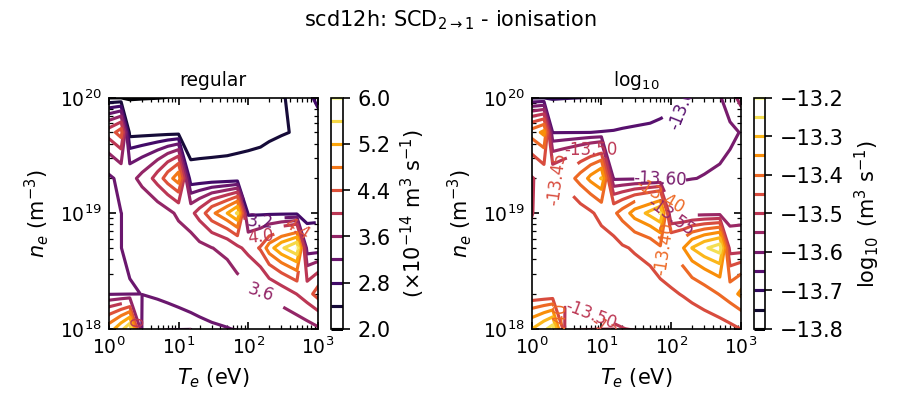

In [15]:
cmap=plt.cm.inferno

fig, ax = plt.subplots(1, 2, figsize=(6,2.75), dpi=150)


N = 14
levels = np.linspace(2e-14*(10**N), 6e-14*(10**N), 11)
cf = ax[0].contour(Te0, ne0, dataIonise*(10**N), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[0], ticks=levels[::2], 
    label=f'($\\times10^{{{-N:.0f}}}$ m$^3$ s$^{{-1}}$)'
)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=5, use_clabeltext=False
)
ax[0].set_xlabel('$T_e$ (eV)')
ax[0].set_ylabel('$n_e$ (m$^{-3}$)')
ax[0].set_xlim([1e0,1e3])
ax[0].set_ylim([1e18,1e20])
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_title('regular', fontsize=9)


levels = np.linspace(-13.8, -13.2, 13)
cf = ax[1].contour(Te0, ne0, np.log10(dataIonise), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[1], ticks=levels[::2], 
    label='$\\log_{10}$ (m$^3$ s$^{-1}$)'
)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlim([1e0,1e3])
ax[1].set_ylim([1e18,1e20])
ax[1].clabel(
    cf, inline=1, fontsize=8, fmt='%1.2f', inline_spacing=5, use_clabeltext=False
)
ax[1].set_xlabel('$T_e$ (eV)')
ax[1].set_ylabel('$n_e$ (m$^{-3}$)')
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_title('$\\log_{10}$', fontsize=9)

fig.suptitle('scd12h: SCD$_{2 \\rightarrow 1}$ - ionisation', fontsize=10)
plt.tight_layout()

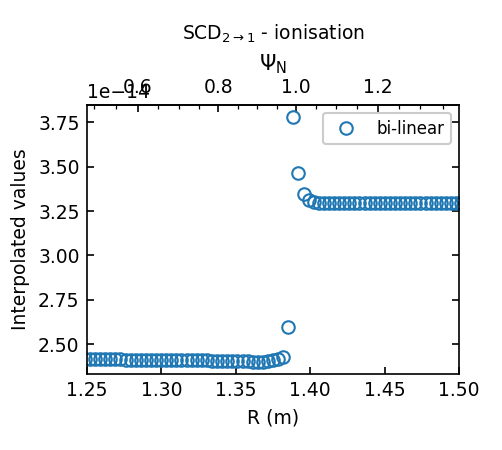

In [16]:
### ionisation
# fIoniseLinear = interp2d(Te0, ne0, dataIonise, kind='linear', bounds_error=True)
# fIoniseCubic = interp2d(Te0, ne0, dataIonise, kind='cubic', bounds_error=True)

# ioniseLinear = np.diag(fIoniseLinear(profileTemp[Rind:], profileDensity[Rind:]))[::-1]
# ioniseCubic = np.diag(fIoniseCubic(profileTemp[Rind:], profileDensity[Rind:]))[::-1]
scaleIonise = 10**int(np.log10(np.median(dataIonise)))
fIonise = RegularGridInterpolator(
    (Te0, ne0), 
    dataIonise.T / scaleIonise, 
    method='linear', 
)
ioniseLinear = fIonise((profileTemp[Rind:], profileDensity[Rind:])) * scaleIonise


fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
ax.plot(RgridB[Rind:], ioniseLinear, 'o', c='C0', mfc='None', label='bi-linear')
# ax.plot(RgridB[Rind:], ioniseCubic, '^', c='C1', mfc='None', label='bi-cubic')
ax.set_title('SCD$_{2 \\rightarrow 1}$ - ionisation', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=False
)
secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.xaxis.set_minor_locator(AutoMinorLocator())
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
            left=False, bottom=False, right=False, top=True)
secax.minorticks_on()
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

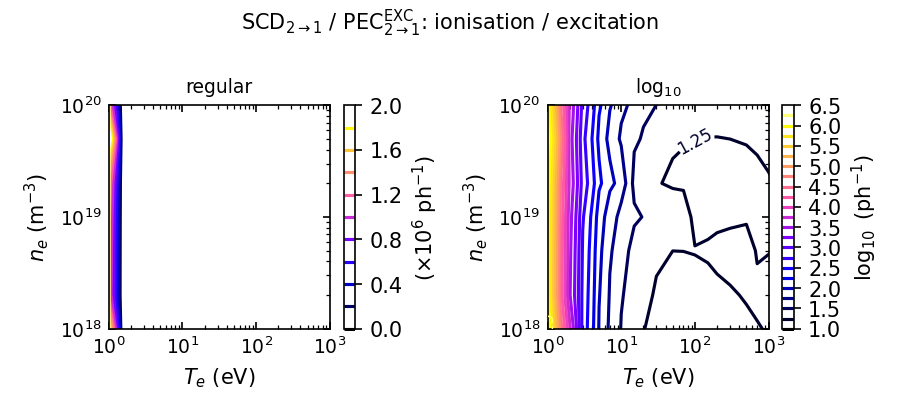

In [17]:
cmap=plt.cm.gnuplot2
Z = dataIonise / dataExcite

fig, ax = plt.subplots(1, 2, figsize=(6,2.75), dpi=150)


N = -6
levels = np.linspace(1e1*(10**N), 2e6*(10**N), 11)
cf = ax[0].contour(Te0, ne0, Z*(10**N), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[0], ticks=levels[::2], 
    label=f'($\\times10^{{{-N:.0f}}}$ ph$^{{-1}}$)'
)
ax[0].set_xscale('log')
ax[0].set_yscale('log')
ax[0].clabel(
    cf, inline=1, fontsize=8, fmt='%1.1f', inline_spacing=5, use_clabeltext=False
)
ax[0].set_xlabel('$T_e$ (eV)')
ax[0].set_ylabel('$n_e$ (m$^{-3}$)')
ax[0].set_xlim([1e0,1e3])
ax[0].set_ylim([1e18,1e20])
ax[0].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[0].set_title('regular', fontsize=9)


levels = np.linspace(1., 6.5, 23)
cf = ax[1].contour(Te0, ne0, np.log10(Z), levels, cmap=cmap)
fig.colorbar(
    cf, ax=ax[1], ticks=levels[::2], 
    label='$\\log_{10}$ (ph$^{-1}$)'
)
ax[1].set_xscale('log')
ax[1].set_yscale('log')
ax[1].set_xlim([1e0,1e3])
ax[1].set_ylim([1e18,1e20])
ax[1].clabel(
    cf, inline=1, fontsize=8, fmt='%1.2f', inline_spacing=5, use_clabeltext=False
)
ax[1].set_xlabel('$T_e$ (eV)')
ax[1].set_ylabel('$n_e$ (m$^{-3}$)')
ax[1].tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=True
)
ax[1].set_title('$\\log_{10}$', fontsize=9)

fig.suptitle('SCD$_{2 \\rightarrow 1}$ / PEC$^\\mathrm{EXC}_{2 \\rightarrow 1}$: ionisation / excitation', fontsize=10)
plt.tight_layout()

/tmp/ipykernel_17256/1118945278.py:2: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  fIonExcRatioLinear = interp2d(Te0, ne0, dataIonise/dataExcite, kind='linear', bounds_error=True)
/tmp/ipykernel_17256/1118945278.py:3: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For sc

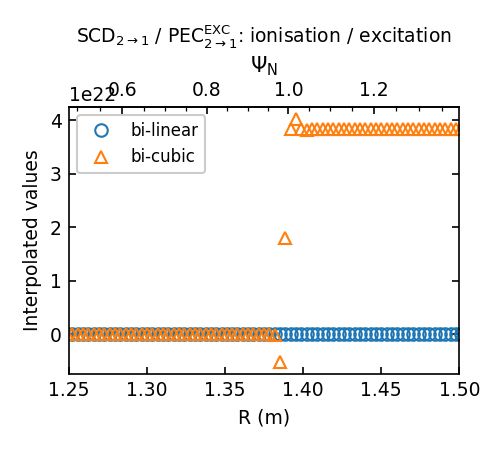

In [18]:
### ionisation
fIonExcRatioLinear = interp2d(Te0, ne0, dataIonise/dataExcite, kind='linear', bounds_error=True)
fIonExcRatioCubic = interp2d(Te0, ne0, dataIonise/dataExcite, kind='cubic', bounds_error=True)

ionExcLinear = np.diag(fIonExcRatioLinear(profileTemp[Rind:], profileDensity[Rind:]))[::-1]
ionExcCubic = np.diag(fIonExcRatioCubic(profileTemp[Rind:], profileDensity[Rind:]))[::-1]


fig, ax = plt.subplots(1, 1, figsize=(3.35,3), dpi=150)
ax.plot(RgridB[Rind:], ionExcLinear, 'o', c='C0', mfc='None', label='bi-linear')
ax.plot(RgridB[Rind:], ionExcCubic, '^', c='C1', mfc='None', label='bi-cubic')
ax.set_title('SCD$_{2 \\rightarrow 1}$ / PEC$^\\mathrm{EXC}_{2 \\rightarrow 1}$: ionisation / excitation', fontsize=9)
ax.legend(fancybox=1, framealpha=1, fontsize=8)
ax.set_xlabel('R (m)', fontsize=9)
ax.set_ylabel('Interpolated values', fontsize=9)
ax.tick_params(
    axis="both", which='both', labelsize=9, direction='in', 
    left=True, bottom=True, right=True, top=False
)
secax = ax.secondary_xaxis('top', functions=(forward, inverse))
secax.xaxis.set_minor_locator(AutoMinorLocator())
secax.set_xlabel('$\\Psi_\\mathrm{N}$')
secax.tick_params(axis="both", which='both', labelsize=9, direction='in', 
            left=False, bottom=False, right=False, top=True)
secax.minorticks_on()
ax.yaxis.get_offset_text().set_size(9)
ax.set_xlim([R0, R1])
plt.tight_layout()

In [19]:
# def calcSiz(emissivity, temperature, density, fExcite, fIonise):
#     SCD = np.diag(fIonise(temperature, density))[::-1]
#     EXC = np.diag(fExcite(temperature, density))[::-1]
#     ionisation = 4. * np.pi * emissivity * SCD / EXC
#     return ionisation


# def calcN0(emissivity, temperature, density, fExcite, fRecomb):
#     REC = np.diag(fRecomb(temperature, density))[::-1] * density * density
#     EXC = np.diag(fExcite(temperature, density))[::-1] * density
#     n0 = ((4. * np.pi * emissivity) - REC) / EXC
#     return n0

def calcSiz(emissivity, temperature, density, fExcite, scaleExcite, fIonise, scaleIonise):
    SCD = fIonise((temperature, density)) * scaleIonise
    EXC = fExcite((temperature, density)) * scaleExcite
    ionisation = 4. * np.pi * emissivity * SCD / EXC
    return ionisation


def calcN0(emissivity, temperature, density, fExcite, scaleExcite, fRecomb, scaleRecomb):
    REC = fRecomb((temperature, density)) * scaleRecomb * density * density
    EXC = fExcite((temperature, density)) * scaleExcite * density
    n0 = ((4. * np.pi * emissivity) - REC) / EXC
    return n0

In [20]:
percentError = 0.10

# Siz = calcSiz(y[0][Rind:], profileTemp[Rind:], profileDensity[Rind:], fExcite, fIonise)
# n0 = calcN0(y[0][Rind:], profileTemp[Rind:], profileDensity[Rind:], fExcite, fRecombCubic)
Siz = calcSiz(y[0][Rind:], profileTemp[Rind:], profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise)
n0 = calcN0(y[0][Rind:], profileTemp[Rind:], profileDensity[Rind:], fExcite, scaleExcite, fRecomb, scaleRecomb)

yLower = y[0] - yErr[0]
yUpper = y[0] + yErr[0]
SizErr = np.zeros((8,len(Siz)))
SizErr[0] = calcSiz(
    yLower[Rind:], (1.-percentError)*profileTemp[Rind:], 
    (1.-percentError)*profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise
)
SizErr[1] = calcSiz(
    yLower[Rind:], (1.-percentError)*profileTemp[Rind:], 
    (1.+percentError)*profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise
)
SizErr[2] = calcSiz(
    yLower[Rind:], (1.+percentError)*profileTemp[Rind:], 
    (1.-percentError)*profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise
)
SizErr[3] = calcSiz(
    yLower[Rind:], (1.+percentError)*profileTemp[Rind:], 
    (1.+percentError)*profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise
)
SizErr[4] = calcSiz(
    yUpper[Rind:], (1.-percentError)*profileTemp[Rind:], 
    (1.-percentError)*profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise
)
SizErr[5] = calcSiz(
    yUpper[Rind:], (1.-percentError)*profileTemp[Rind:], 
    (1.+percentError)*profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise
)
SizErr[6] = calcSiz(
    yUpper[Rind:], (1.+percentError)*profileTemp[Rind:], 
    (1.-percentError)*profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise
)
SizErr[7] = calcSiz(
    yUpper[Rind:], (1.+percentError)*profileTemp[Rind:], 
    (1.+percentError)*profileDensity[Rind:], fExcite, scaleExcite, fIonise, scaleIonise
)
# SizUpper = SizErr.max(axis=0)
# SizLower = SizErr.min(axis=0)
SizUpper = Siz + np.abs(SizErr - Siz).max(axis=0)
SizLower = Siz - np.abs(SizErr - Siz).max(axis=0)


n0Err = np.zeros((8,len(n0)))
n0Err[0] = calcN0(
    yLower[Rind:], (1.-percentError)*profileTemp[Rind:], 
    (1.-percentError)*profileDensity[Rind:], fExcite, scaleExcite, fRecomb, scaleRecomb
)
n0Err[1] = calcN0(
    yLower[Rind:], (1.-percentError)*profileTemp[Rind:], 
    (1.+percentError)*profileDensity[Rind:], fExcite, scaleExcite, fRecomb, scaleRecomb
)
n0Err[2] = calcN0(
    yLower[Rind:], (1.+percentError)*profileTemp[Rind:], 
    (1.-percentError)*profileDensity[Rind:], fExcite, scaleExcite, fRecomb, scaleRecomb
)
n0Err[3] = calcN0(
    yLower[Rind:], (1.+percentError)*profileTemp[Rind:], 
    (1.+percentError)*profileDensity[Rind:], fExcite, scaleExcite, fRecomb, scaleRecomb
)
n0Err[4] = calcN0(
    yUpper[Rind:], (1.-percentError)*profileTemp[Rind:], 
    (1.-percentError)*profileDensity[Rind:], fExcite, scaleExcite, fRecomb, scaleRecomb
)
n0Err[5] = calcN0(
    yUpper[Rind:], (1.-percentError)*profileTemp[Rind:], 
    (1.+percentError)*profileDensity[Rind:], fExcite, scaleExcite, fRecomb, scaleRecomb
)
n0Err[6] = calcN0(
    yUpper[Rind:], (1.+percentError)*profileTemp[Rind:], 
    (1.-percentError)*profileDensity[Rind:], fExcite, scaleExcite, fRecomb, scaleRecomb
)
n0Err[7] = calcN0(
    yUpper[Rind:], (1.+percentError)*profileTemp[Rind:], 
    (1.+percentError)*profileDensity[Rind:], fExcite, scaleExcite, fRecomb, scaleRecomb
)
# n0Upper = n0Err.max(axis=0)
# n0Lower = n0Err.min(axis=0)
n0Upper = n0 + np.abs(n0Err - n0).max(axis=0)
n0Lower = n0 - np.abs(n0Err - n0).max(axis=0)

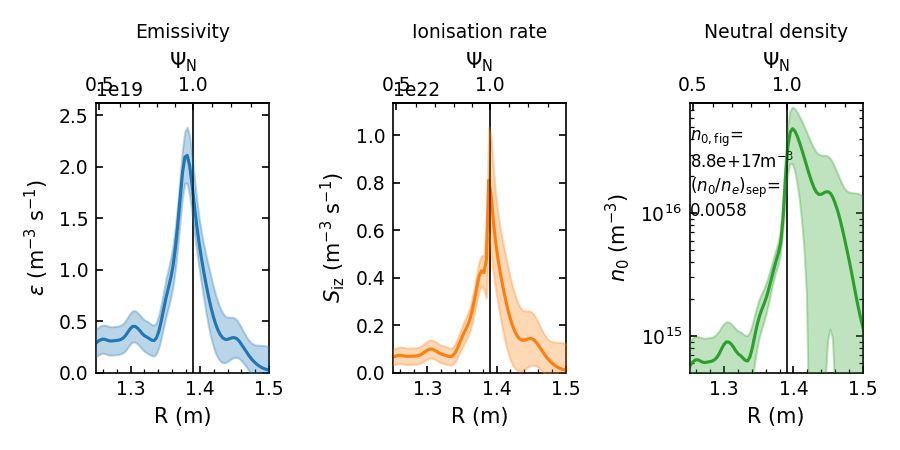

In [25]:
figPressure = HSV.calcFigPressure(shotn, twant, fig='mid')
figN0 = HSV.calcFigDensity(figPressure, T=300.)
densityRatioSep = (n0 / profileDensity[Rind:])[HSV.findNearest(psiN[Rind-psind:], 1.)]

R1 = 1.5
Rind1 = HSV.findNearest(RgridB[Rind:], R1)

fig, ax = plt.subplots(1, 3, figsize=(6,3), dpi=150)


ax[0].plot(RgridB[Rind:], y[0][Rind:], '-', c='C0', mfc='None')
ax[0].fill_between(
    RgridB[Rind:], y[0][Rind:]-yErr[0][Rind:], 
    y[0][Rind:]+yErr[0][Rind:], color='C0', alpha=0.3, zorder=5
)
ax[0].set_title('Emissivity', fontsize=9)
ax[0].set_xlabel('R (m)')
ax[0].set_ylabel('$\\epsilon$ (m$^{-3}$ s$^{-1}$)')
ax[0].yaxis.get_offset_text().set_size(9)
ax[0].set_ylim([0., (y[0]+yErr[0]).max()*yMult])


ax[1].plot(RgridB[Rind:], Siz, '-', c='C1', mfc='None')
ax[1].fill_between(
    RgridB[Rind:], SizLower, SizUpper, color='C1', alpha=0.3, zorder=5
)
ax[1].set_title('Ionisation rate', fontsize=9)
ax[1].set_xlabel('R (m)')
ax[1].set_ylabel('$S_\\mathrm{iz}$ (m$^{-3}$ s$^{-1}$)')
ax[1].yaxis.get_offset_text().set_size(9)
ax[1].set_ylim([0., SizUpper.max()*yMult])


ax[2].plot(RgridB[Rind:], n0, '-', c='C2', mfc='None')
ax[2].fill_between(
    RgridB[Rind:], n0Lower, n0Upper, color='C2', alpha=0.3, zorder=5
)
ax[2].set_title('Neutral density', fontsize=9)
ax[2].set_xlabel('R (m)')
ax[2].set_ylabel('$n_0$ (m$^{-3}$)')
ax[2].yaxis.get_offset_text().set_size(9)
ax[2].set_ylim([n0[:Rind1].min()/yMult, n0Upper.max()*yMult])
ax[2].set_yscale('log')




for i in range(0, 3):
#     ax[i].plot([R0, R1], [0., 0.], '-k', lw=0.8)
    ax[i].set_xlim([R0, R1])
    ax[i].tick_params(
        axis="both", which='both', labelsize=9, direction='in', 
        left=True, bottom=True, right=True, top=False
    )
    ax[i].xaxis.set_minor_locator(AutoMinorLocator())
    secax = ax[i].secondary_xaxis('top', functions=(forward, inverse))
    secax.xaxis.set_minor_locator(AutoMinorLocator())
    secax.set_xlabel('$\\Psi_\\mathrm{N}$')
    secax.tick_params(
        axis="both", which='both', labelsize=9, direction='in', 
                left=False, bottom=False, right=False, top=True
    )
    secax.minorticks_on()

ax[0].plot([sepR, sepR], [0., (y[0]+yErr[0]).max()*yMult], '-k', lw=0.8)
ax[1].plot([sepR, sepR], [0., SizUpper.max()*yMult], '-k', lw=0.8)
ax[2].plot([sepR, sepR], [0., n0Upper.max()*yMult], '-k', lw=0.8)
ax[2].text(
    R0, n0.max(), 
    f'$n_{{0,\\mathrm{{fig}}}}$=\n{figN0:.2g}m$^{{-3}}$\n' + \
    f'$(n_0/n_e)_\\mathrm{{sep}}$=\n{densityRatioSep:.4f}', 
    color='k', fontsize=8, va='top', ha='left'
)
    
plt.tight_layout()

In [ ]:
from pyEquilibrium.equilibrium import equilibrium as equil

In [ ]:
eq = equil(device='MASTU', shot=49091, time=0.5)
surface10 = eq.get_fluxsurface(1.0)
Rsurface10 = surface10.R
Zsurface10 = surface10.Z

surface11 = eq.get_fluxsurface(1.1)
Rsurface11 = surface11.R
Zsurface11 = surface11.Z

surface90 = eq.get_fluxsurface(0.90)
Rsurface90 = surface90.R
Zsurface90 = surface90.Z

surface80 = eq.get_fluxsurface(0.80)
Rsurface80 = surface80.R
Zsurface80 = surface80.Z

surface70 = eq.get_fluxsurface(0.70)
Rsurface70 = surface70.R
Zsurface70 = surface70.Z

surface60 = eq.get_fluxsurface(0.60)
Rsurface60 = surface60.R
Zsurface60 = surface60.Z

surface50 = eq.get_fluxsurface(0.50)
Rsurface50 = surface50.R
Zsurface50 = surface50.Z

fig, ax = plt.subplots(1, 1)
ax.plot(Rsurface50, Zsurface50)
ax.plot(Rsurface60, Zsurface60)
ax.plot(Rsurface70, Zsurface70)
ax.plot(Rsurface80, Zsurface80)
ax.plot(Rsurface90, Zsurface90)
ax.plot(Rsurface10, Zsurface10)
ax.plot(Rsurface11, Zsurface11)
ax.set_aspect('equal')
ax.set_ylim([-1.2,1.2])

In [ ]:
Rsurface11.max()

In [ ]:
Zsurface50[Rsurface50.argmax()]

In [ ]:
Zsurface11[Rsurface11.argmax()]

In [ ]:
psiWant = 1.1
surface = eq.get_fluxsurface(psiWant)
Rsurface = surface.R
Zsurface = surface.Z
phi = np.deg2rad(
    np.zeros_like(Rsurface) + 183.31530946836227
)
allSurface = np.vstack((Rsurface, Zsurface, phi)).T
np.savetxt(f'plateandbracket_surface_49091_0.500_psi_{psiWant:.1f}.txt', allSurface)

In [ ]:
pwd

In [ ]:
client.get('/epm/output/profiles2D/r', 49091).data

In [ ]:
import my_funcs as mf

In [ ]:
mf.cart2cyl(np.array([1.,1.,0.])), np.rad2deg(np.arctan2(1.,1.))

In [ ]:
mf.cart2cyl(np.array([-1.,1.,0.])), np.rad2deg(np.arctan2(1.,-1.))

In [2]:
mf.cart2cyl(np.array([1.,-1.,0.])), np.rad2deg(np.arctan2(-1.,1.)) + 360.

NameError: name 'mf' is not defined

In [ ]:
mf.cart2cyl(np.array([-1.,-1.,0.])), np.rad2deg(np.arctan2(-1.,-1.)) + 360.

In [ ]:
np.rad2deg(np.arctan2(1.,1.))

In [ ]:
# HSV.getRz('/home/sthoma/tokamak_inversion_routines/mastu/rba_viewing_49091.npz', )